# Lab 6 — Dynamic 3D / 4D Worlds: adding a time axis to point clouds

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab06_dynamic_4d_worlds/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 6 · Spatial track**

Labs 0–3 learned world models on 2D images and low-dimensional states; modules 03–04 of the spatial track covered **static** 3D representations (point clouds, NeRF, 3D Gaussian Splatting). But the real world moves: people walk, cars drive, hands grasp. Static representations have a fundamental flaw in dynamic scenes: they cannot answer **"where will it be a second from now?"**

This lab adds a time axis to 3D representations, i.e. **4D = 3D + time**. We don't do large-scale 4D reconstruction. Instead we generate a mini dynamic scene in code (three point-cloud objects with different motions: a cube with rigid rotation + translation, a sphere in uniform circular motion, a "breathing" deforming blob, all observed with noise) and then do the following:

```
noisy point-cloud sequence (x, y, z) × T frames
        │
        ├─ ① Motion estimation   centroid tracking + ICP-style registration → scene flow (per-point motion field)
        ├─ ② Temporal interpolation   x(t+α) = x(t) + α · flow, "creating" frames between two frames
        └─ ③ Dynamics learning   MLP: (p_t, v_t) → Δp, extrapolate 10 future frames ← what a world model's prediction looks like in 3D space
```

The teaching point: **a 4D representation is the dynamic extension of a spatial world model**. You will see with your own eyes that the information a static (x, y, z) representation throws away is exactly the information needed to predict the future.

## 1. Motivation — static 3D cannot answer "where will it be a second from now?"

A point cloud $(x, y, z)$ is a **snapshot**: it tells you what the world's geometry looks like at one moment, but has no dimension that indexes time. Attach timestamps and frame-to-frame correspondences to get $(x, y, z, t)$, and the representation really becomes a **world model whose state evolves over time**.

The difference is not one extra coordinate in form, but one of capability:

| Question | Static 3D (x,y,z) | Dynamic 4D (x,y,z,t) |
|---|---|---|
| What shape is this object? | ✅ | ✅ |
| Where is it heading right now? | ❌ (no velocity) | ✅ |
| What happened between two frames? | ❌ | ✅ (temporal interpolation) |
| Where will it be in 5 seconds? | ❌ | ✅ (dynamics extrapolation) |

What autonomous driving cares about has never been "what does this car look like" but "will it enter my lane in 0.5 seconds". The core parts of this lab map exactly onto the full chain from snapshot to prediction: **estimate motion → interpolate the past → fit dynamics → extrapolate the future**.

## 2. Setup

**Why:** The only heavy dependency is PyTorch (the CPU build is enough, and Colab has it preinstalled); `imageio` saves the per-frame 3D scatter plots as GIFs, and `matplotlib` handles 3D visualization. The first cell detects Colab and installs anything missing; the whole lab runs on CPU within a few minutes.

In [1]:
# @title setup
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio"), ("matplotlib", "matplotlib")]:
    ensure(pkg, name)

import io
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
rng = np.random.default_rng(0)
T_CLOCK = time.time()   # timer for the whole notebook
print("torch", torch.__version__, "| device: cpu | colab:", IN_COLAB)


torch 2.14.0+cu130 | device: cpu | colab: False


## 3. Environment & Dataset — a mini dynamic 3D scene

**Why:** To study dynamic representations we first need a dynamic world where "we know the full truth". We generate $T = 60$ frames of point clouds with 3 objects per frame in code, and each of the three motions has its own teaching role:

- **cube**: rigid motion, uniform translation + uniform rotation about the $z$ axis. It is home turf for the constant-velocity model and the test subject for ICP registration.
- **sphere**: uniform **circular** motion, with a persistent acceleration. Constant-velocity extrapolation must fail here, so it is the showcase for learned dynamics.
- **blob**: bobbing up and down (sinusoidal) + **breathing non-rigid deformation** (pulsing scale). The rigid assumption breaks here.

Observation model: every frame adds Gaussian noise ($\sigma = 0.02$) to the true point cloud, simulating a depth camera's measurement error. Object segmentation (which point belongs to which object) is assumed known; in a real system a 3D detector / tracker provides it, and it is not the focus of this lab.

**Key design**: the centroid motion of all three objects is Markov: the next-frame displacement $\Delta p$ is a deterministic function of the current state $(p, v)$. This guarantees that the dynamics model in Section 5 is learnable in principle.

In [2]:
T, N_PTS, NOISE_STD = 60, 150, 0.02

def sphere_pts(n, r, rng):
    v = rng.normal(size=(n, 3))
    return r * v / np.linalg.norm(v, axis=1, keepdims=True)

# canonical space: each object's "reference shape"; the world point cloud at every time is a transform of it
CANON = {
    "cube":   rng.uniform(-0.35, 0.35, size=(N_PTS, 3)),
    "sphere": sphere_pts(N_PTS, 0.30, rng),
    "blob":   sphere_pts(N_PTS, 0.28, rng),
}

# motion parameters
OMEGA_CUBE = 0.06                                   # cube rotation about z per step (rad)
V_CUBE = np.array([0.030, 0.020, 0.010])            # cube translation per step
P0_CUBE = np.array([-1.0, -0.2, 0.0])
OMEGA_SPH, R_ORB, Z_ORB = 0.15, 0.8, 0.5            # sphere orbit: angular velocity / radius / height
BLOB_CENTER = np.array([0.9, -0.6, 0.0])
BLOB_AMP, BLOB_OMEGA = 0.25, 0.3                    # blob centroid sinusoid along z: amplitude / angular velocity
BREATH_AMP, BREATH_OMEGA = 0.3, 0.35                # blob non-rigid breathing: amplitude / angular velocity

def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

def cube_pose(t):   return P0_CUBE + V_CUBE * t, Rz(OMEGA_CUBE * t)
def sphere_c(t):    return np.array([R_ORB * np.cos(OMEGA_SPH * t), R_ORB * np.sin(OMEGA_SPH * t), Z_ORB])
def blob_c(t):      return BLOB_CENTER + np.array([0.0, 0.0, 0.3 + BLOB_AMP * np.sin(BLOB_OMEGA * t)])
def blob_scale(t):  return 1.0 + BREATH_AMP * np.sin(BREATH_OMEGA * t)

def world_frame(t):
    """ground-truth world point cloud (noise-free)"""
    p, R = cube_pose(t)
    return {
        "cube":   CANON["cube"] @ R.T + p,                    # rigid: rotation + translation
        "sphere": CANON["sphere"] + sphere_c(t),              # rigid: pure translation
        "blob":   CANON["blob"] * blob_scale(t) + blob_c(t),  # non-rigid: deformation + translation
    }

gt_frames  = [world_frame(t) for t in range(T)]
obs_frames = [{k: v + rng.normal(0, NOISE_STD, size=v.shape) for k, v in f.items()}
              for f in gt_frames]
gt_centroids  = {k: np.stack([f[k].mean(0) for f in gt_frames])  for k in CANON}  # (T, 3)
est_centroids = {k: np.stack([f[k].mean(0) for f in obs_frames]) for k in CANON}

NAMES = list(CANON)
print(f"{T} frames × {len(NAMES)} objects × {N_PTS} points | noise σ = {NOISE_STD}")
print("centroid tracking error (noisy obs vs gt):",
      {k: round(float(np.linalg.norm(est_centroids[k] - gt_centroids[k], axis=1).mean()), 5) for k in NAMES})


60 frames × 3 objects × 150 points | noise σ = 0.02
centroid tracking error (noisy obs vs gt): {'cube': 0.00242, 'sphere': 0.00268, 'blob': 0.00249}


### 3.1 Static (x, y, z) vs dynamic (x, y, z, t): the difference at a glance

The same cube, viewed two ways. The left plot is the **static representation**: a cloud of points at frame 20, with a complete shape but no information at all about "where it is going". The right plot stacks all 60 frames into **spacetime**: the x and y axes are space, the vertical axis is time, and the point cloud stretches into a **trajectory tube**. The direction of motion, velocity and acceleration are all written into the shape of the tube.

That is the essence of a 4D representation: not storing one more number, but making "the history of the world" a first-class citizen of the representation.

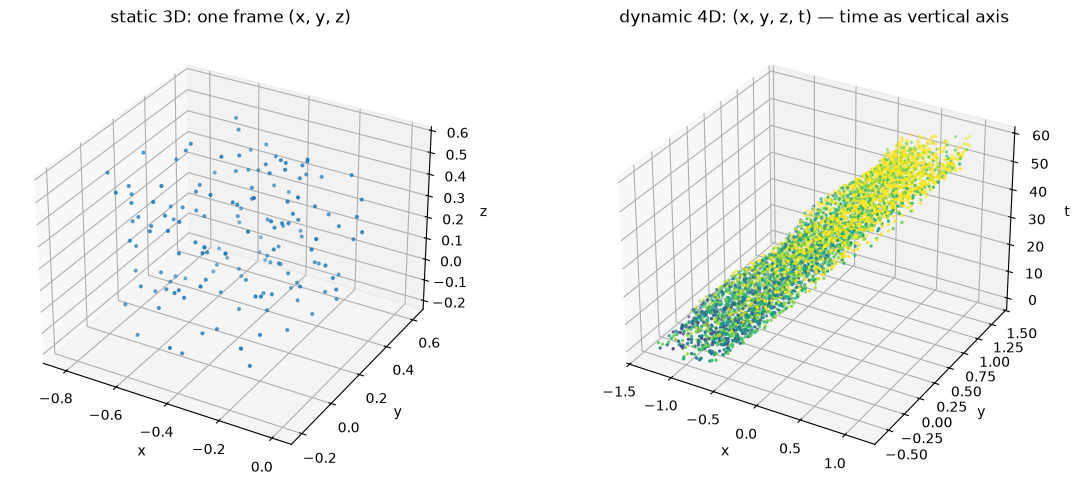

saved assets/static_vs_dynamic.png


In [3]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121, projection="3d")
pts = obs_frames[20]["cube"]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4, c="#1f77b4")
ax.set_title("static 3D: one frame (x, y, z)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax = fig.add_subplot(122, projection="3d")
for t in range(0, T, 2):                      # one layer every 2 frames to avoid clutter
    pts = obs_frames[t]["cube"]
    ax.scatter(pts[:, 0], pts[:, 1], np.full(len(pts), t), s=2, c=pts[:, 2],
               cmap="viridis", vmin=-0.5, vmax=0.5)
ax.set_title("dynamic 4D: (x, y, z, t) — time as vertical axis")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("t")

plt.tight_layout()
plt.savefig("assets/static_vs_dynamic.png", dpi=90, bbox_inches="tight")
plt.show()
print("saved assets/static_vs_dynamic.png")


## 4. Build the Model — motion estimation: centroid tracking + ICP-style registration

**Why:** Before predicting the future, we have to read "motion" out of neighboring frames. At two granularities:

1. **Object level — centroid tracking**: the mean of each object's points (its centroid) is a robust estimate of translation (`est_centroids` was already computed above). Simple and noise-resistant, but it discards rotation and deformation.
2. **Point level — scene flow / ICP**: a per-point motion field. We use nearest-neighbor matching to set up frame-to-frame correspondences $p_i \mapsto q_{\text{nn}(i)}$, which gives the flow vectors; for the rigid object (the cube) we then iterate **nearest-neighbor matching + a Kabsch solve** (SVD for the optimal rotation) to recover $(R, t)$. That is the core loop of ICP (Iterative Closest Point), all hand-written in under 20 lines.

Nearest-neighbor matching is only reliable when **the frame-to-frame displacement is smaller than the point spacing**, which is its known weak spot (see the questions in Section 9). We run ICP on the cube and score it against the known ground-truth relative pose.

ICP on cube, frames 10->11:
  rotation error : 1.33 deg  (gt per-step rotation = 3.44 deg)
  translation err: 0.0184  (gt step |v| = 0.0374)


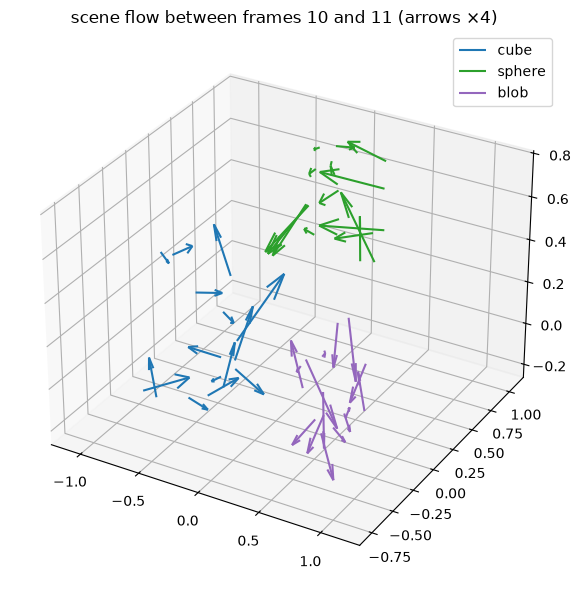

In [4]:
def nn_correspondences(P, Q):
    """for each p_i, the index of its nearest point in Q"""
    d2 = ((P[:, None, :] - Q[None, :, :]) ** 2).sum(-1)
    return np.argmin(d2, axis=1)

def icp_rigid(P, Q, iters=5):
    """estimate R, t such that Q ≈ P @ R.T + t: iterate nearest-neighbor matching + a Kabsch (SVD) solve"""
    R, t = np.eye(3), np.zeros(3)
    for _ in range(iters):
        Pw = P @ R.T + t
        Qm = Q[nn_correspondences(Pw, Q)]
        pc, qc = Pw.mean(0), Qm.mean(0)
        U, _, Vt = np.linalg.svd((Pw - pc).T @ (Qm - qc))
        dR = Vt.T @ U.T
        if np.linalg.det(dR) < 0:          # forbid reflections
            Vt[-1] *= -1
            dR = Vt.T @ U.T
        R, t = dR @ R, dR @ t + (qc - pc @ dR.T)
    return R, t

def scene_flow(P, Q):
    """per-point motion field: flow_i = q_nn(i) - p_i"""
    return Q[nn_correspondences(P, Q)] - P

# --- test ICP on the cube's (frame 10, frame 11) ---
t_pair = 10
R_hat, t_hat = icp_rigid(obs_frames[t_pair]["cube"], obs_frames[t_pair + 1]["cube"])

# ground-truth relative pose: x_{t+1} = R_rel · x_t + t_rel
p0_, R0_ = cube_pose(t_pair)
p1_, R1_ = cube_pose(t_pair + 1)
R_rel = R1_ @ R0_.T
t_rel = p1_ - p0_ @ R_rel.T

angle_err = np.degrees(np.arccos(np.clip((np.trace(R_rel.T @ R_hat) - 1) / 2, -1, 1)))
print(f"ICP on cube, frames {t_pair}->{t_pair + 1}:")
print(f"  rotation error : {angle_err:.2f} deg  (gt per-step rotation = {np.degrees(OMEGA_CUBE):.2f} deg)")
print(f"  translation err: {np.linalg.norm(t_hat - t_rel):.4f}  (gt step |v| = {np.linalg.norm(V_CUBE):.4f})")

# --- scene flow visualization ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
COLORS = {"cube": "#1f77b4", "sphere": "#2ca02c", "blob": "#9467bd"}
for k in NAMES:
    P = obs_frames[t_pair][k]
    F = scene_flow(P, obs_frames[t_pair + 1][k])
    sub = slice(0, N_PTS, 10)                       # one arrow every 10 points
    ax.quiver(P[sub, 0], P[sub, 1], P[sub, 2], F[sub, 0], F[sub, 1], F[sub, 2],
              color=COLORS[k], length=4.0, arrow_length_ratio=0.3, label=k)
ax.legend()
ax.set_title(f"scene flow between frames {t_pair} and {t_pair + 1} (arrows ×4)")
plt.tight_layout()
plt.savefig("assets/scene_flow.png", dpi=90, bbox_inches="tight")
plt.show()


### 4.2 Dynamics model: constant-velocity extrapolation vs a learned MLP

**Why:** Centroid tracking gives a centroid trajectory $\{p_t\}$, with velocity from a finite difference $v_t = p_t - p_{t-1}$. Doing world-model-style prediction in 3D space means learning a dynamics model $(p_t, v_t) \mapsto \Delta p$ and then feeding its predictions back into itself **autoregressively** (an open-loop rollout, structurally identical to the latent version in Lab 2).

Two candidates, one extremely simple and one learnable:

- **Constant-velocity (CV) baseline**: $\Delta p = v_t$, zero parameters. Theoretically optimal for the cube, and bound to fail systematically on circular/sinusoidal motion.
- **MLP dynamics**: a 2-layer MLP with input $(p, v) \in \mathbb{R}^6$ and output $\Delta p \in \mathbb{R}^3$. The acceleration of circular motion is a function of position, so an MLP can learn it, provided the training data covers the state space.

In [5]:
class DynamicsMLP(nn.Module):
    """(p, v) -> Δp: a tiny 3D dynamics model"""
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 3),
        )

    def forward(self, p, v):
        return self.net(torch.cat([p, v], dim=-1))

def cv_step(p, v):
    """constant-velocity baseline: displacement = current velocity, zero parameters"""
    return v

@torch.no_grad()
def rollout(model_step, p0, v0, steps):
    """open-loop autoregressive extrapolation: feed each prediction back into the model"""
    p, v, path = p0.copy(), v0.copy(), [p0.copy()]
    for _ in range(steps):
        if isinstance(model_step, nn.Module):
            dp = model_step(torch.as_tensor(p, dtype=torch.float32),
                            torch.as_tensor(v, dtype=torch.float32)).numpy()
        else:
            dp = model_step(p, v)
        p, v = p + dp, dp          # new velocity = the displacement just taken
        path.append(p.copy())
    return np.stack(path)          # (steps+1, 3)


## 5. Train — fitting dynamics on the tracked centroid trajectories

**Why:** The training signal is one-step supervision: state $(p_t, v_t)$ → observed displacement $\Delta p_t = p_{t+1} - p_t$. We **deliberately train only on the first 49 frames and keep the last 10 frames as the exam for future prediction**. Training a model that has seen the whole world and then letting it "predict" frames inside its training set would be fooling ourselves.

The data is the `est_centroids` from Section 4 (centroids of the noisy observations), not the ground truth, because a real system has no god's-eye view. After averaging over 150 points the noise drops to the order of $10^{-3}$ and barely affects training.

training pairs: 147  (3 objects × 49 transitions)


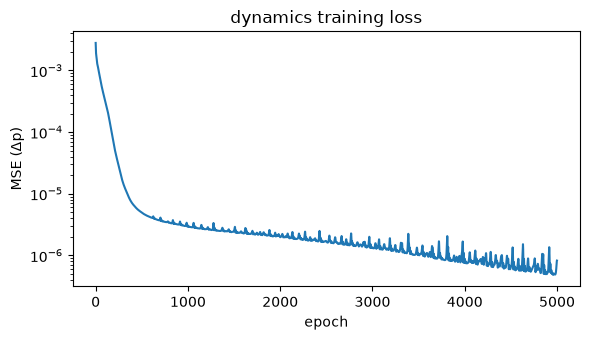

final train MSE: 8.25e-07


In [6]:
H = 10                       # predict 10 future frames
T0 = T - 1 - H               # rollout start: frame 49 (last 10 frames held out for evaluation)

X, Y = [], []
for k in NAMES:
    c = est_centroids[k]
    for t in range(T0):
        X.append(np.concatenate([c[t], c[t + 1] - c[t]]))     # (p_t, v_t)
        Y.append(c[t + 1] - c[t])                             # Δp_t
X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(np.array(Y), dtype=torch.float32)
print(f"training pairs: {len(X)}  ({len(NAMES)} objects × {T0} transitions)")

dyn = DynamicsMLP(hidden=32)
opt = torch.optim.Adam(dyn.parameters(), lr=1e-3)
losses = []
for epoch in range(5000):
    opt.zero_grad()
    loss = ((dyn(X[:, :3], X[:, 3:]) - Y) ** 2).mean()
    loss.backward()
    opt.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (Δp)")
plt.title("dynamics training loss")
plt.tight_layout()
plt.savefig("assets/training_loss.png", dpi=90, bbox_inches="tight")
plt.show()
print(f"final train MSE: {losses[-1]:.2e}")


## 6. Visualize — making the world move

First, an animation of the raw observation sequence: 60 frames of noisy point clouds, with the camera slowly orbiting. Note each object's motion personality: the cube rotates while it travels, the sphere circles, the blob breathes in place.

In [7]:
def fig_to_array(fig, dpi=70):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi)
    buf.seek(0)
    img = imageio.imread(buf)
    plt.close(fig)
    return img

all_pts = np.concatenate([np.concatenate([f[k] for k in NAMES]) for f in gt_frames])
lo, hi = all_pts.min(0) - 0.2, all_pts.max(0) + 0.2

def draw_scene(ax, clouds, title="", alpha=0.9):
    for k in NAMES:
        pts = clouds[k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=COLORS[k], alpha=alpha)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((1, 1, 0.8))
    ax.set_title(title)

frames = []
for t in range(T):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    draw_scene(ax, obs_frames[t], title=f"dynamic scene · t = {t:02d}")
    ax.view_init(elev=20, azim=-60 + t)          # camera orbits slowly
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/dynamic_scene.gif", frames, duration=0.12, loop=0)
print("saved assets/dynamic_scene.gif  |", len(frames), "frames")


saved assets/dynamic_scene.gif  | 60 frames


### 6.1 Temporal interpolation: "creating" frames between two frames

**Why:** Sensors have a discrete frame rate, but the world is continuous. With the scene flow estimated in Section 4, and assuming the motion between frames is **uniform**, we can synthesize any intermediate moment:

$$\hat{x}(t + \alpha) = x(t) + \alpha \cdot \text{flow}_i, \qquad \alpha \in [0, 1]$$

This is a toy version of how D-NeRF / 4D-GS can query the scene at any time $t$; they replace our linear approximation with a learnable deformation field $\Delta_\psi(x, t)$. We interpolate 4 intermediate moments between frames 10 and 11 ($\alpha = 0.2, 0.4, 0.6, 0.8$), turning 1 step into 6 frames of slow motion.

In [8]:
t_pair = 10
flows = {k: scene_flow(obs_frames[t_pair][k], obs_frames[t_pair + 1][k]) for k in NAMES}
ALPHAS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

frames = []
for a in ALPHAS:
    interp = {k: obs_frames[t_pair][k] + a * flows[k] for k in NAMES}
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    label = f"t = {t_pair}" if a == 0 else (f"t = {t_pair + 1}" if a == 1 else f"t = {t_pair}+{a:.1f} (interpolated)")
    draw_scene(ax, interp, title=label)
    ax.view_init(elev=20, azim=-45)
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/interpolation.gif", frames, duration=0.35, loop=0)
print("saved assets/interpolation.gif | 6 frames: 2 real + 4 synthesized in-between")

# numeric sanity check: interpolation at α=1 should coincide with the real frame 11 (error = flow matching error)
err = {k: float(np.linalg.norm(obs_frames[t_pair][k] + flows[k] - obs_frames[t_pair + 1][k], axis=1).mean())
       for k in NAMES}
print("interpolation error at α=1 (mean per-point distance to real next frame):",
      {k: round(v, 4) for k, v in err.items()})


saved assets/interpolation.gif | 6 frames: 2 real + 4 synthesized in-between
interpolation error at α=1 (mean per-point distance to real next frame): {'cube': 0.0293, 'sphere': 0.104, 'blob': 0.067}


## 7. Evaluate — predicting 10 future frames

**Why:** This is where the whole lab lands, and it is the most direct form of the world-model idea in 3D space: standing at frame 49, give the model only the current state $(p_{49}, v_{49})$, let it **extrapolate 10 future frames open-loop** (frames 50–59), and compare against the ground truth.

- Metrics: **ADE** (Average Displacement Error, the mean position error over 10 steps) and **FDE** (Final Displacement Error, the error at the last step), the standard metrics in trajectory prediction.
- Expected plot: on the cube, the zero-parameter CV model is nearly perfect (a constant-velocity world paired with a constant-velocity model); on the sphere's circular motion, CV's error explodes with the horizon, and the centripetal acceleration the MLP learned starts to pay off.
- Also look at how the MLP does on the cube: it exposes a classic weakness of learned dynamics, discussed in Section 9.

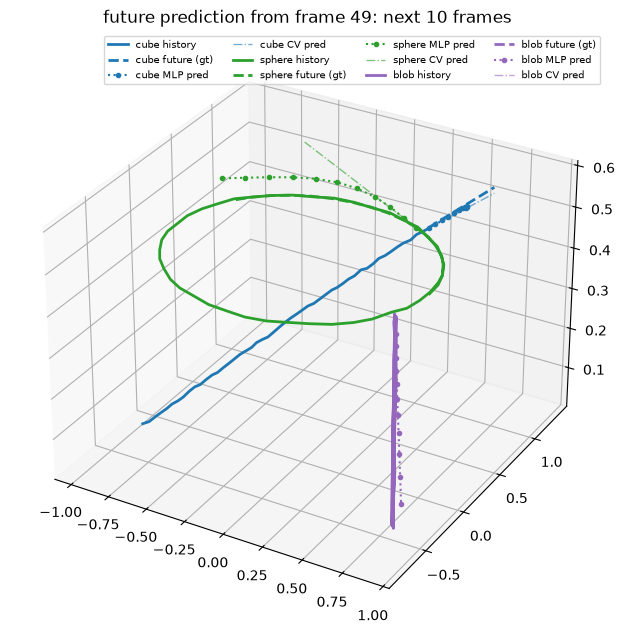

object   model      ADE      FDE
cube     CV     0.0088   0.0143
cube     MLP    0.0492   0.1687
sphere   CV     0.3586   0.8940
sphere   MLP    0.0838   0.1698
blob     CV     0.1528   0.1547
blob     MLP    0.1308   0.1143


In [9]:
pred_mlp, pred_cv = {}, {}
for k in NAMES:
    c = est_centroids[k]
    p0, v0 = c[T0], c[T0] - c[T0 - 1]
    pred_mlp[k] = rollout(dyn, p0, v0, H)
    pred_cv[k]  = rollout(cv_step, p0, v0, H)

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection="3d")
for k in NAMES:
    hist = est_centroids[k][:T0 + 1]
    fut  = gt_centroids[k][T0:T0 + H + 1]
    ax.plot(hist[:, 0], hist[:, 1], hist[:, 2], c=COLORS[k], lw=2, label=f"{k} history")
    ax.plot(fut[:, 0], fut[:, 1], fut[:, 2], c=COLORS[k], lw=2, ls="--", label=f"{k} future (gt)")
    ax.plot(pred_mlp[k][:, 0], pred_mlp[k][:, 1], pred_mlp[k][:, 2], c=COLORS[k], lw=1.5, ls=":", marker=".", label=f"{k} MLP pred")
    ax.plot(pred_cv[k][:, 0], pred_cv[k][:, 1], pred_cv[k][:, 2], c=COLORS[k], lw=1, ls="-.", alpha=0.6, label=f"{k} CV pred")
ax.legend(fontsize=7, ncol=4)
ax.set_title(f"future prediction from frame {T0}: next {H} frames")
plt.tight_layout()
plt.savefig("assets/future_trajectories.png", dpi=90, bbox_inches="tight")
plt.show()

print(f"{'object':8s} {'model':4s} {'ADE':>8s} {'FDE':>8s}")
for k in NAMES:
    g = gt_centroids[k][T0 + 1:T0 + H + 1]
    for name, pr in [("CV", pred_cv[k]), ("MLP", pred_mlp[k])]:
        e = np.linalg.norm(pr[1:] - g, axis=1)
        print(f"{k:8s} {name:4s} {e.mean():8.4f} {e[-1]:8.4f}")


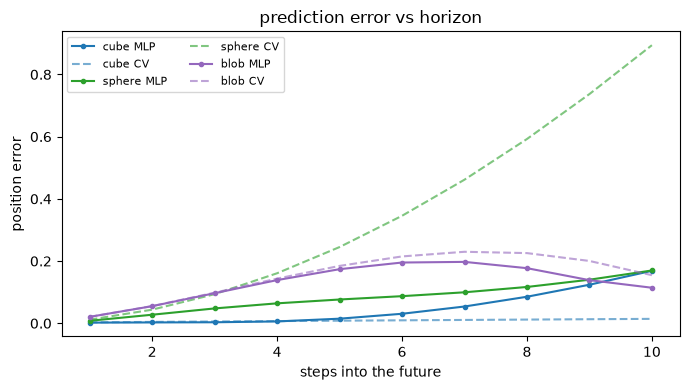

saved assets/prediction.gif | 11 frames
total notebook time so far: 15.1 s


In [10]:
# --- per-frame error curves: how error grows with the horizon ---
plt.figure(figsize=(7, 4))
for k in NAMES:
    g = gt_centroids[k][T0 + 1:T0 + H + 1]
    e_mlp = np.linalg.norm(pred_mlp[k][1:] - g, axis=1)
    e_cv  = np.linalg.norm(pred_cv[k][1:] - g, axis=1)
    plt.plot(range(1, H + 1), e_mlp, c=COLORS[k], ls="-", marker="o", ms=3, label=f"{k} MLP")
    plt.plot(range(1, H + 1), e_cv, c=COLORS[k], ls="--", alpha=0.6, label=f"{k} CV")
plt.xlabel("steps into the future"); plt.ylabel("position error")
plt.title("prediction error vs horizon"); plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("assets/prediction_error.png", dpi=90, bbox_inches="tight")
plt.show()

# --- predicted vs actual: apply the predicted centroid motion to the last observed point cloud (rigid assumption) ---
frames = []
for k_step in range(H + 1):
    t = T0 + k_step
    shifted = {k: obs_frames[T0][k] + (pred_mlp[k][k_step] - est_centroids[k][T0]) for k in NAMES}
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    for k in NAMES:   # actual
        pts = obs_frames[t][k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=COLORS[k], alpha=0.9, label=f"{k} actual")
    for k in NAMES:   # predicted
        pts = shifted[k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c="red", alpha=0.35, marker="x")
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((1, 1, 0.8))
    ax.scatter([], [], [], c="red", marker="x", label="predicted (MLP)")
    ax.legend(fontsize=7, loc="upper left")
    ax.set_title(f"predicted vs actual · t = {t}")
    ax.view_init(elev=20, azim=-45)
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/prediction.gif", frames, duration=0.35, loop=0)
print("saved assets/prediction.gif |", len(frames), "frames")
print(f"total notebook time so far: {time.time() - T_CLOCK:.1f} s")


## 8. Experiment

### ✏️ Exercise 1 — What if the non-rigid deformation is more extreme?

Change `BREATH_AMP` from 0.3 to 0.8 and `BREATH_OMEGA` from 0.35 to 0.8, then rerun every cell from Section 3 on. Observe:

1. Are the blob's scene-flow arrows still regular?
2. Is centroid tracking affected? Why does deformation affect the centroid little "on average"?
3. In the prediction GIF, does the gap between the red predicted point cloud (rigid-translation assumption) and the blue actual blob grow?

**Hint:** You only need to change two constants in Section 3 and rerun; think about which link in the "rigid translation + centroid dynamics" pipeline breaks first under non-rigid deformation.

In [11]:
# YOUR CODE HERE
# hint: BREATH_AMP, BREATH_OMEGA = 0.8, 0.8, then rerun Sections 3–7
pass


### ✏️ Exercise 2 — Occlusion between objects and dropped points

Real depth cameras have occlusion: when objects block each other, the hidden part has **no observation at all** in that frame. Modify the observation-generation code: drop 30% of each object's points at random every frame (`obs = pts[rng.choice(len(pts), size=int(0.7*len(pts)), replace=False)]`), or go further and remove the points hidden along the line of sight when the sphere passes behind the cube. After rerunning, answer:

1. How much does the centroid-tracking error grow? (Hint: random dropping is unbiased, but **occlusion dropping is biased**, since it is always the same side that gets hidden.)
2. How does ICP's rotation-estimation error change? Why is nearest-neighbor matching more fragile on sparse point clouds?
3. Which concept from module 05 does this correspond to? (observability / insufficient observation)

In [12]:
# YOUR CODE HERE
# hint: add random point dropping where obs_frames is generated; for biased occlusion, look along -y and remove points sorted by depth
pass


### ✏️ Exercise 3 — The limits of the prediction horizon

Set `H` to 5 and to 20 and rerun Sections 5–7 for each (note that `T0` follows automatically), and plot both ADE/FDE curves together:

1. Which model is more sensitive to the horizon, the MLP or CV?
2. At H = 20, what shape is the sphere's MLP error curve: monotonically increasing, or structured? (Think about the periodicity of circular motion.)
3. Together with the drift curve from Lab 2: what are the two sources of error growth in open-loop extrapolation? How would you correct with observations (echoing the update step of the Lab 1 Kalman filter)?

**Hint:** Change only the constant `H`; for question 2, the prediction error for circular motion is theoretically bounded by the orbit's diameter.

In [13]:
# YOUR CODE HERE
# hint: H = 5 / 20, rerun Sections 5–7 and compare ADE/FDE
pass


## 9. Questions

1. **The fundamental flaw of static representations**: why can a static point cloud $(x, y, z)$, however precise, never answer "where will it be a second from now" in principle? What kind of state variable is it missing?
2. **When nearest-neighbor matching fails**: when does the NN correspondence of scene flow mismatch? (Name at least: frame-to-frame displacement vs point spacing, repeated/symmetric structures, uneven density.) What do real scene-flow methods (such as FlowNet3D, NSFP) use instead of hard matching?
3. **Why CV wins on the cube**: constant velocity beats an MLP trained for 5000 epochs on the cube. What weakness of learned dynamics does this expose (hint: during rollout, $(p, v)$ leaves the training distribution)? What does it suggest about "when to learn a model and when to use a hand-written prior"?
4. **From linear interpolation to deformation fields**: our temporal interpolation assumes uniform straight-line motion between frames. Why is the canonical space + deformation field paradigm of D-NeRF / 4D-GS more general? How does its way of answering "the world at any time $t$" fundamentally differ from ours?

## 10. Takeaways

- **4D = 3D + time**: a static point cloud $(x,y,z)$ is a snapshot; a 4D representation $(x,y,z,t)$ makes motion and history first-class citizens of the representation. It is the dynamic extension of a spatial world model, and a step from "reconstructing photos" toward "modeling the world".
- **Motion estimation** turns a frame sequence into raw material for dynamics: centroid tracking gives object-level translation, the hand-written ICP-style registration (NN matching + Kabsch/SVD iterations) recovers rigid poses, and scene flow gives a per-point motion field. NN matching is quite reliable when the frame-to-frame displacement is smaller than the point spacing (ICP rotation error ~1° in this lab).
- **Temporal interpolation** is a direct dividend of flow: $x(t+\alpha) = x(t) + \alpha\cdot\text{flow}$ synthesizes slow motion between two frames. Real 4D representations (D-NeRF, 4D-GS) generalize this to any time and any viewpoint with a learnable deformation field.
- **Future prediction is what a world model looks like in 3D space**: MLP dynamics clearly beat the constant-velocity prior on circular/sinusoidal motion; but on uniform straight-line motion, the zero-parameter CV is more accurate. A learned model has no guarantees when extrapolating outside its training distribution, and open-loop error compounds with the horizon (structurally identical to Lab 2's drift).
- A static representation cannot answer "where will it be a second from now"; for a spatial representation to become a world model, it has to model how the state evolves along the time dimension explicitly.

**Next**: Module 06 State Estimation ([spatial/06-state-estimation](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/spatial/06-state-estimation)): when noisy observations keep arriving, how do you alternate "predict" and "correct" (exactly what the Lab 1 Kalman filter looks like in 3D tracking)?

*Course: World Models & Spatial Intelligence. Related: DynamicFusion (2015); D-NeRF (2021); 4D Gaussian Splatting (2024); FlowNet3D (2018).*